# Standard Deep Neural Network (DNN) - Google Colab Compatible

## Instructions:
1. **Enable GPU** (optional but recommended): Runtime → Change runtime type → GPU → Save
2. **To force CPU**: Runtime → Change runtime type → None → Save
3. Run all cells in order
4. Download the `baseline_results.csv` at the end to use with DP_DNN

---

## 1. Install Dependencies

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Device selection (CUDA > CPU)
# To force CPU: Runtime → Change runtime type → None
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device('cpu')
    print(f"✓ Using CPU")

print(f"\nPyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


✓ Using CPU

PyTorch version: 2.11.0
Device: cpu


## 4. Load Data

In [2]:
import pickle

# Load the preprocessed data
with open("../data/processed_data.pkl", "rb") as f:
    loaded_data = pickle.load(f)

X_train, X_test = loaded_data["X_train"], loaded_data["X_test"]
y_train, y_test = loaded_data["y_train"], loaded_data["y_test"]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✓ Data loaded and prepared")
print(f"  Batch size: {batch_size}")

Training set: (455, 30)
Test set: (114, 30)

✓ Data loaded and prepared
  Batch size: 32


## 5. Define Neural Network

In [3]:
class DNNClassifier(nn.Module):
    def __init__(self, input_size=30, hidden_sizes=[64, 32], num_classes=2, dropout=0.2):
        super(DNNClassifier, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Hyperparameters
input_size = 30
hidden_sizes = [64, 32]
num_classes = 2
dropout = 0.2
learning_rate = 0.001
num_epochs = 50

print(f"Model Architecture:")
print(f"  Input: {input_size} features")
print(f"  Hidden layers: {hidden_sizes}")
print(f"  Output: {num_classes} classes")
print(f"  Dropout: {dropout}")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {num_epochs}")

Model Architecture:
  Input: 30 features
  Hidden layers: [64, 32]
  Output: 2 classes
  Dropout: 0.2
  Learning rate: 0.001
  Epochs: 50


## 6. Training Functions

In [4]:
def train_model(model, train_loader, criterion, optimizer, num_epochs, device, verbose=False):
    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    return train_losses

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("✓ Training functions defined")

✓ Training functions defined


## 7. Train Standard DNN (30 Runs)

In [5]:
N_RUNS = 30

detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_roc_auc = []
detail_cms = []

print(f"Training Standard DNN {N_RUNS} times...")
print("="*60)

extra = ExtraMetrics()
for run in range(N_RUNS):
    seed = run * 10 + 42

    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    model = DNNClassifier(input_size, hidden_sizes, num_classes, dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    _t0 = time.perf_counter()
    train_losses = train_model(model, train_loader, criterion, optimizer, num_epochs, device)
    train_time = time.perf_counter() - _t0
    # Training-partition score for the non-private fit.
    y_train_true, y_train_pred, _ = evaluate_model(model, train_loader, device)
    y_true, y_pred, y_prob = evaluate_model(model, test_loader, device)

    accuracy = accuracy_score(y_true, y_pred)
    extra.add(y_true, y_pred, y_score=y_prob, train_true=y_train_true, train_pred=y_train_pred, train_time=train_time)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    detail_accuracies.append(accuracy)
    detail_f1s.append(f1)
    detail_precisions.append(precision)
    detail_recalls.append(recall)
    detail_roc_auc.append(roc_auc)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {accuracy:.4f} | F1: {f1:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")

print("="*60)
print("✓ Training complete")

Training Standard DNN 30 times...


  Run  1/30 | Acc: 0.9737 | F1: 0.9630 | Prec: 1.0000 | Rec: 0.9286
  Run  2/30 | Acc: 0.9825 | F1: 0.9756 | Prec: 1.0000 | Rec: 0.9524


  Run  3/30 | Acc: 0.9737 | F1: 0.9630 | Prec: 1.0000 | Rec: 0.9286
  Run  4/30 | Acc: 0.9737 | F1: 0.9630 | Prec: 1.0000 | Rec: 0.9286


  Run  5/30 | Acc: 0.9737 | F1: 0.9630 | Prec: 1.0000 | Rec: 0.9286
  Run  6/30 | Acc: 0.9825 | F1: 0.9756 | Prec: 1.0000 | Rec: 0.9524


  Run  7/30 | Acc: 0.9825 | F1: 0.9756 | Prec: 1.0000 | Rec: 0.9524


...

  Run 21/30 | Acc: 0.9825 | F1: 0.9756 | Prec: 1.0000 | Rec: 0.9524
  Run 22/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048


  Run 23/30 | Acc: 0.9737 | F1: 0.9639 | Prec: 0.9756 | Rec: 0.9524
  Run 24/30 | Acc: 0.9825 | F1: 0.9756 | Prec: 1.0000 | Rec: 0.9524


  Run 25/30 | Acc: 0.9737 | F1: 0.9630 | Prec: 1.0000 | Rec: 0.9286
  Run 26/30 | Acc: 0.9737 | F1: 0.9630 | Prec: 1.0000 | Rec: 0.9286


  Run 27/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048
  Run 28/30 | Acc: 0.9825 | F1: 0.9756 | Prec: 1.0000 | Rec: 0.9524


  Run 29/30 | Acc: 0.9737 | F1: 0.9639 | Prec: 0.9756 | Rec: 0.9524
  Run 30/30 | Acc: 0.9737 | F1: 0.9630 | Prec: 1.0000 | Rec: 0.9286
✓ Training complete


In [6]:
# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model

export_model(model, 'output/model/std_dnn_model.pkl')

PyTorch model successfully exported to output/model/std_dnn_model.pkl


## 8. Evaluation Results

In [7]:
accuracy = float(np.mean(detail_accuracies))
f1 = float(np.mean(detail_f1s))
precision = float(np.mean(detail_precisions))
recall = float(np.mean(detail_recalls))
roc_auc = float(np.mean(detail_roc_auc))

std_accuracy = float(np.std(detail_accuracies))
std_f1 = float(np.std(detail_f1s))

print("=" * 60)
print("STANDARD DNN - EVALUATION METRICS")
print("=" * 60)
print(f"Runs:      {N_RUNS}")
print(f"Accuracy:  {accuracy:.4f} ± {std_accuracy:.4f}")
print(f"F1-Score:  {f1:.4f} ± {std_f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

STANDARD DNN - EVALUATION METRICS
Runs:      30
Accuracy:  0.9734 ± 0.0070
F1-Score:  0.9626 ± 0.0102
Precision: 0.9959
Recall:    0.9317
ROC-AUC:   0.9960


## 9. Confusion Matrix

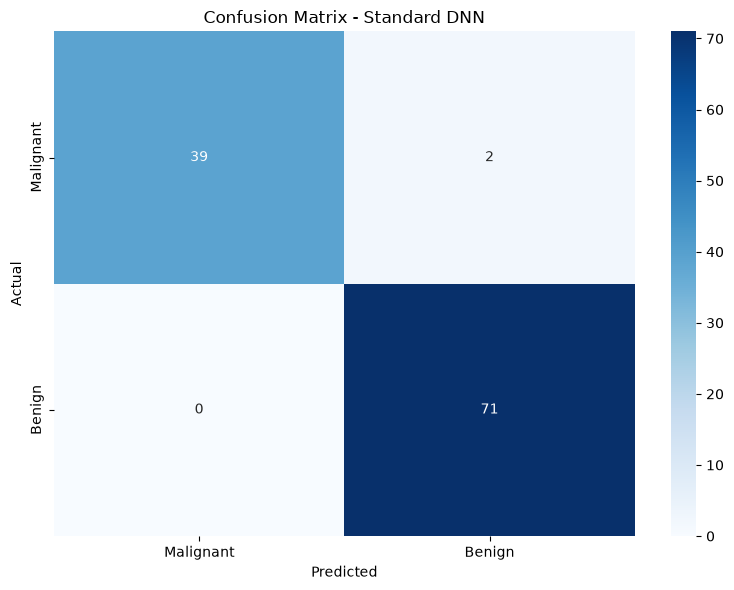


Confusion Matrix:
[[39  2]
 [ 0 71]]


In [8]:
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN],
    [FP, TN]
])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Standard DNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)

## 10. Save Baseline Results

In [9]:
import json

# Save baseline for comparison with DP-DNN
baseline_results = {
    'model': 'Standard DNN',
    'architecture': str(hidden_sizes),
    'accuracy': accuracy,
    'f1_score': f1,
    'precision': precision,
    'recall': recall,
    'roc_auc': roc_auc
}
baseline_results.update(extra.means())

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('baseline_results.csv', index=False)

# Also save JSON report
parameters = {
    "architecture": "DNN",
    "input_size": input_size,
    "hidden_sizes": hidden_sizes,
    "num_classes": num_classes,
    "dropout": dropout,
    "learning_rate": learning_rate,
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "optimizer": "Adam"
}

results_json = {
    "model_type": "Standard DNN",
    "accuracy": accuracy,
    "confusion_matrix": avg_cm.tolist(),
    "parameters": parameters
}
results_json.update(extra.means())

with open('std_dnn_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("✓ Results saved to 'baseline_results.csv' and 'std_dnn_report.json'")
print("\nBaseline Summary:")
print(baseline_df)

print("Added metrics:")
print(extra.describe())

✓ Results saved to 'baseline_results.csv' and 'std_dnn_report.json'

Baseline Summary:
          model architecture  accuracy  f1_score  precision    recall  \
0  Standard DNN     [64, 32]  0.973392  0.962584   0.995935  0.931746   

    roc_auc  train_accuracy  balanced_accuracy  train_time  
0  0.996032        0.985055           0.964716     0.18979  
Added metrics:
  Train Acc:      0.9851 ± 0.0034
  Balanced Acc:   0.9647 ± 0.0097
  AUROC:          0.9960 ± 0.0006
  Train Time (s): 0.1898 ± 0.0214
